In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
deliveries = pd.read_csv(r"C:\Users\ssumi\OneDrive\Desktop\I.P.L\deliveries.csv")
matches = pd.read_csv(r"C:\Users\ssumi\OneDrive\Desktop\I.P.L\matches.csv")

print("matches Shape:", matches.shape)
print("deliveries Shape:", deliveries.shape)

matches Shape: (1095, 20)
deliveries Shape: (260920, 17)


In [14]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [17]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [18]:
matches.dtypes

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

In [19]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [20]:
matches.season.unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [21]:
def normalize_season(season):
    if season == '2020/21':
        return 2020  
    elif '/' in season:
        start, end = season.split('/')
        return int(start[:2] + end) 
    else:
        return int(season)
        
matches['season'] = matches['season'].map(normalize_season)

In [22]:
matches.season.unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024])

In [23]:
matches['season'].value_counts()

season
2013    76
2022    74
2012    74
2023    74
2011    73
2024    71
2019    60
2016    60
2010    60
2021    60
2020    60
2014    60
2018    60
2017    59
2015    59
2008    58
2009    57
Name: count, dtype: int64

In [24]:
matches['city'].value_counts()

city
Mumbai            173
Kolkata            93
Delhi              90
Chennai            85
Hyderabad          77
Bangalore          65
Chandigarh         61
Jaipur             57
Pune               51
Abu Dhabi          37
Ahmedabad          36
Bengaluru          29
Visakhapatnam      15
Durban             15
Lucknow            14
Dubai              13
Dharamsala         13
Centurion          12
Rajkot             10
Sharjah            10
Navi Mumbai         9
Indore              9
Johannesburg        8
Ranchi              7
Cuttack             7
Cape Town           7
Port Elizabeth      7
Raipur              6
Kochi               5
Mohali              5
Kanpur              4
East London         3
Kimberley           3
Nagpur              3
Guwahati            3
Bloemfontein        2
Name: count, dtype: int64

In [26]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [28]:
matches['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [29]:
team_corrections = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}

matches['team1'] = matches['team1'].replace(team_corrections)
matches['team2'] = matches['team2'].replace(team_corrections)

In [30]:
matches["team1"].value_counts()

team1
Royal Challengers Bangalore    144
Chennai Super Kings            128
Delhi Capitals                 126
Mumbai Indians                 123
Punjab Kings                   123
Kolkata Knight Riders          121
Rajasthan Royals               101
Sunrisers Hyderabad             86
Deccan Chargers                 39
Pune Warriors                   23
Lucknow Super Giants            23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiants         14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [31]:
matches["team2"].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Delhi Capitals                 126
Punjab Kings                   123
Rajasthan Royals               120
Royal Challengers Bangalore    111
Chennai Super Kings            110
Sunrisers Hyderabad             96
Deccan Chargers                 36
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Rising Pune Supergiants         16
Gujarat Lions                   14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [32]:
matches["winner"].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils',
       'Royal Challengers Bangalore', 'Rajasthan Royals',
       'Kings XI Punjab', 'Deccan Chargers', 'Mumbai Indians',
       'Pune Warriors', 'Kochi Tuskers Kerala', nan,
       'Sunrisers Hyderabad', 'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [33]:
team_corrections = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}
matches['winner'] = matches['winner'].replace(team_corrections)

In [34]:
matches["winner"].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Capitals',
       'Royal Challengers Bangalore', 'Rajasthan Royals', 'Punjab Kings',
       'Deccan Chargers', 'Mumbai Indians', 'Pune Warriors',
       'Kochi Tuskers Kerala', nan, 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions', 'Gujarat Titans',
       'Lucknow Super Giants'], dtype=object)

In [35]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [36]:
matches['city'] = matches['city'].fillna('Unknown')

In [37]:
print(matches['city'].isna().sum())
print(matches['city'].unique())

0
['Bangalore' 'Chandigarh' 'Delhi' 'Mumbai' 'Kolkata' 'Jaipur' 'Hyderabad'
 'Chennai' 'Cape Town' 'Port Elizabeth' 'Durban' 'Centurion' 'East London'
 'Johannesburg' 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur'
 'Dharamsala' 'Kochi' 'Indore' 'Visakhapatnam' 'Pune' 'Raipur' 'Ranchi'
 'Abu Dhabi' 'Unknown' 'Rajkot' 'Kanpur' 'Bengaluru' 'Dubai' 'Sharjah'
 'Navi Mumbai' 'Lucknow' 'Guwahati' 'Mohali']


In [38]:
matches["method"].unique()

array([nan, 'D/L'], dtype=object)

In [39]:
matches['method'] = matches['method'].fillna('Non D/L')
matches["method"].unique()

array(['Non D/L', 'D/L'], dtype=object)

In [40]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [41]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [42]:
deliveries["batting_team"].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Kings XI Punjab', 'Rajasthan Royals',
       'Delhi Daredevils', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [43]:
deliveries["bowling_team"].unique()

array(['Royal Challengers Bangalore', 'Kolkata Knight Riders',
       'Kings XI Punjab', 'Chennai Super Kings', 'Delhi Daredevils',
       'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [44]:
team_correction = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}
deliveries["batting_team"] = deliveries["batting_team"].replace(team_correction)
deliveries["bowling_team"] = deliveries["bowling_team"].replace(team_correction)

In [45]:
deliveries["batting_team"].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Punjab Kings', 'Rajasthan Royals',
       'Delhi Capitals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions', 'Lucknow Super Giants',
       'Gujarat Titans'], dtype=object)

In [46]:
deliveries["bowling_team"].unique()

array(['Royal Challengers Bangalore', 'Kolkata Knight Riders',
       'Punjab Kings', 'Chennai Super Kings', 'Delhi Capitals',
       'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions', 'Gujarat Titans',
       'Lucknow Super Giants'], dtype=object)

In [47]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [48]:
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna("Not Out")
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna("No Dismissal")
deliveries['fielder'] = deliveries['fielder'].fillna("Not Applicable")

In [49]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed         0
dismissal_kind           0
fielder                  0
dtype: int64

In [50]:
set(deliveries['match_id']) - set(matches['id'])

set()

In [51]:
match_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
match_runs.columns = ['id', 'total_match_runs']

matches = matches.merge(match_runs, on='id', how='left')

In [52]:
team_wins = matches['winner'].value_counts()
team_matches = matches['team1'].value_counts() + matches['team2'].value_counts()

win_percentage = (team_wins / team_matches * 100).sort_values(ascending=False)
win_percentage.head(10)

Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.235294
Delhi Capitals                 45.634921
Name: count, dtype: float64

In [53]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]
impact = (len(toss_win_match_win) / len(matches)) * 100

print("Toss Win Impact:", round(impact,2), "%")

Toss Win Impact: 43.29 %


In [54]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batsmen

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

In [55]:
batsman_runs = deliveries.groupby('batter')['batsman_runs'].sum()
balls_faced = deliveries.groupby('batter')['ball'].count()
strike_rate = (batsman_runs / balls_faced) * 100

sr_df = pd.DataFrame({
    'runs': batsman_runs,
    'balls': balls_faced,
    'strike_rate': strike_rate
})

sr_df = sr_df[sr_df['balls'] > 1000]
sr_df.sort_values('strike_rate', ascending=False).head(10)

,runs,balls,strike_rate
batter,,,
AD Russell,2488,1515,164.224422
N Pooran,1769,1143,154.768154
GJ Maxwell,2772,1842,150.488599
V Sehwag,2728,1833,148.827059
AB de Villiers,5181,3487,148.580442
YBK Jaiswal,1607,1095,146.757991
RR Pant,3297,2296,143.597561
PP Shaw,1892,1321,143.224830
SA Yadav,3594,2522,142.505948


In [56]:
bowler_runs = deliveries.groupby('bowler')['total_runs'].sum()
bowler_balls = deliveries.groupby('bowler')['ball'].count()
economy = (bowler_runs / bowler_balls) * 6

eco_df = pd.DataFrame({
    'runs_conceded': bowler_runs,
    'balls_bowled': bowler_balls,
    'economy': economy
})

eco_df = eco_df[eco_df['balls_bowled'] > 500]
eco_df.sort_values('economy').head(10)

,runs_conceded,balls_bowled,economy
bowler,,,
A Kumble,1089,983,6.646999
M Muralitharan,1765,1581,6.698292
SP Narine,4672,4146,6.761216
DW Steyn,2583,2282,6.791411
DL Vettori,894,785,6.833121
Rashid Khan,3340,2901,6.907963
J Botha,818,709,6.922426
R Ashwin,5435,4679,6.969438
MM Ali,900,770,7.012987


In [57]:
venue_analysis = matches.groupby('venue')['total_match_runs'].mean().sort_values(ascending=False).head(10)
venue_analysis

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: total_match_runs, dtype: float64

In [58]:
venue_analysis = matches.groupby('venue')['total_match_runs'].mean().sort_values(ascending=False).head(10)
venue_analysis

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    400.000000
Arun Jaitley Stadium, Delhi                                           380.687500
Eden Gardens, Kolkata                                                 380.312500
M Chinnaswamy Stadium, Bengaluru                                      380.142857
Himachal Pradesh Cricket Association Stadium, Dharamsala              378.750000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      371.200000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  364.846154
Brabourne Stadium                                                     348.100000
Punjab Cricket Association IS Bindra Stadium                          347.600000
Wankhede Stadium, Mumbai                                              346.377778
Name: total_match_runs, dtype: float64

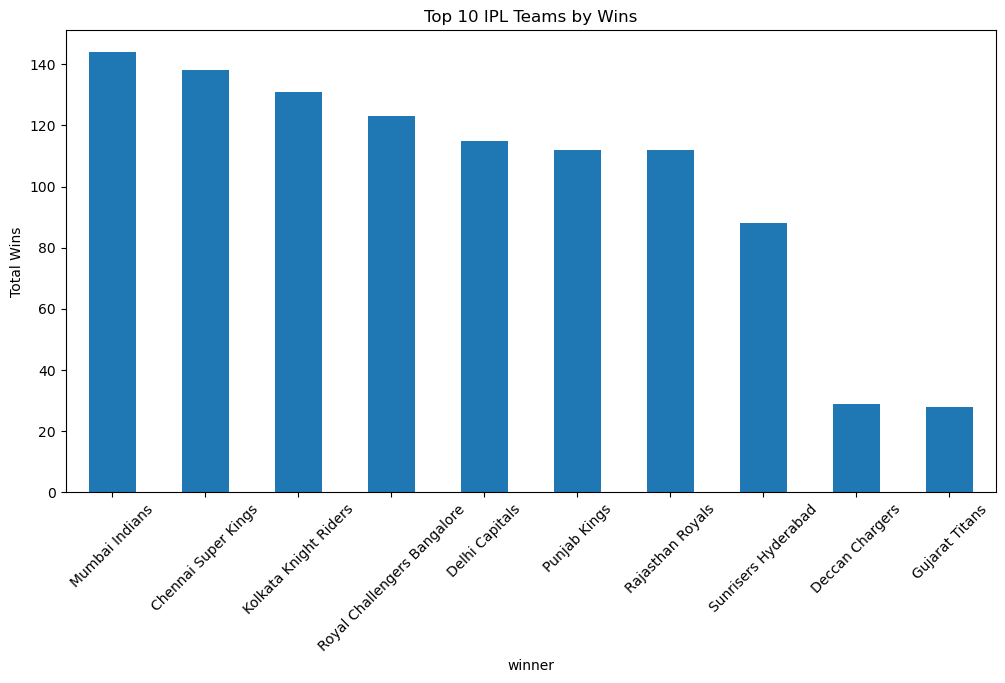

In [59]:
plt.figure(figsize=(12,6))
team_wins.head(10).plot(kind='bar')
plt.title("Top 10 IPL Teams by Wins")
plt.ylabel("Total Wins")
plt.xticks(rotation=45)
plt.show()